In [1]:
import numpy as np
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

# Number of students
n_students = 1000

# 1. Generate Study Hours (Right-skewed distribution, average ~3 hours/day)
study_hours = np.random.lognormal(mean=1.1, sigma=0.4, size=n_students)
study_hours = np.clip(study_hours, 0.5, 12).round(2) # Cap between 0.5 and 12 hours

# 2. Generate Attendance (%)
# Higher study hours correlate with higher attendance
base_attendance = 50 + 4 * study_hours
attendance = base_attendance + np.random.normal(loc=0, scale=8, size=n_students)
attendance = np.clip(attendance, 40, 100).astype(int) # Cap between 40% and 100%

# 3. Generate Sleep Hours (Normal distribution, average ~7 hours)
sleep_hours = np.random.normal(loc=7.0, scale=1.2, size=n_students)
sleep_hours = np.clip(sleep_hours, 4.0, 11.0).round(2)

# 4. Generate Lifestyle / Extracurricular Involvement (1 to 5 scale)
# Inverse relationship with study hours
stress_levels = np.clip(10 - (0.5 * study_hours) + np.random.normal(0, 1.5, n_students), 1, 10).round(2)

# 5. Generate Exam Scores (0 to 100 scale)
# Score is driven by Study Hours and Attendance, with added statistical noise
base_score = 25 + (10 * study_hours) + (0.3 * attendance)
exam_scores = base_score + np.random.normal(loc=0, scale=8, size=n_students)
exam_scores = np.clip(exam_scores, 0, 100).round(2)

# 6. Assign Categorical Variables
# Higher attendance leads to a higher probability of passing
passed = np.where(exam_scores >= 40, 'Yes', 'No')
extracurricular_hours = np.random.randint(0, 15, size=n_students)
stress_category = pd.cut(stress_levels, bins=[0, 4, 7, 10], labels=['Low', 'Moderate', 'High'])

# Create DataFrame
df = pd.DataFrame({
    'Student_ID': [f'STU_{i:04d}' for i in range(1, n_students + 1)],
    'Study_Hours_Per_Day': study_hours,
    'Attendance_Rate_Percentage': attendance,
    'Sleep_Hours_Per_Day': sleep_hours,
    'Extracurricular_Hours_Per_Week': extracurricular_hours,
    'Stress_Level': stress_category,
    'Exam_Score': exam_scores,
    'Passed': passed
})

# Display the first 5 records
print(df.head())

# Save to CSV
df.to_csv('student_performance_dataset.csv', index=False)


  Student_ID  Study_Hours_Per_Day  Attendance_Rate_Percentage  \
0   STU_0001                 3.66                          75   
1   STU_0002                 2.84                          68   
2   STU_0003                 3.89                          66   
3   STU_0004                 5.52                          66   
4   STU_0005                 2.74                          66   

   Sleep_Hours_Per_Day  Extracurricular_Hours_Per_Week Stress_Level  \
0                 6.19                               7     Moderate   
1                 6.83                               0         High   
2                 6.05                               7         High   
3                 6.63                               5         High   
4                 4.73                               3         High   

   Exam_Score Passed  
0       77.19    Yes  
1       73.55    Yes  
2       83.84    Yes  
3      100.00    Yes  
4       61.27    Yes  


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
from google.colab import files
uploaded = files.upload()

Saving student_performance_dataset.csv to student_performance_dataset (1).csv


In [12]:
df = pd.read_csv("student_performance_dataset.csv")

print(df.head())

  Student_ID  Study_Hours_Per_Day  Attendance_Rate_Percentage  \
0   STU_0001                 3.66                          75   
1   STU_0002                 2.84                          68   
2   STU_0003                 3.89                          66   
3   STU_0004                 5.52                          66   
4   STU_0005                 2.74                          66   

   Sleep_Hours_Per_Day  Extracurricular_Hours_Per_Week Stress_Level  \
0                 6.19                               7     Moderate   
1                 6.83                               0         High   
2                 6.05                               7         High   
3                 6.63                               5         High   
4                 4.73                               3         High   

   Exam_Score Passed  
0       77.19    Yes  
1       73.55    Yes  
2       83.84    Yes  
3      100.00    Yes  
4       61.27    Yes  


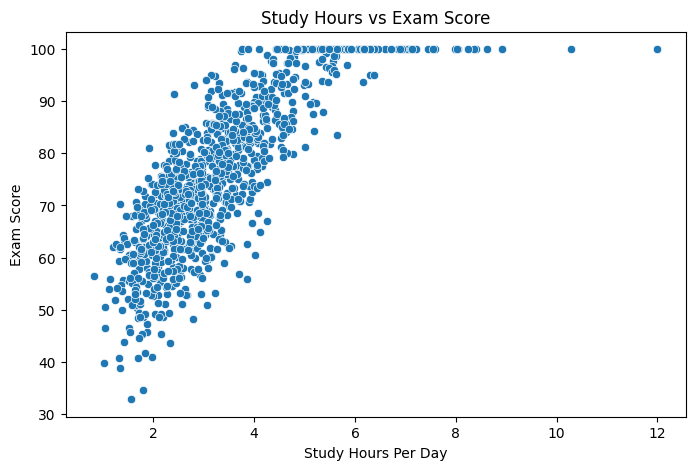

In [13]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Study_Hours_Per_Day',
    y='Exam_Score',
    data=df
)

plt.title("Study Hours vs Exam Score")
plt.xlabel("Study Hours Per Day")
plt.ylabel("Exam Score")

plt.show()

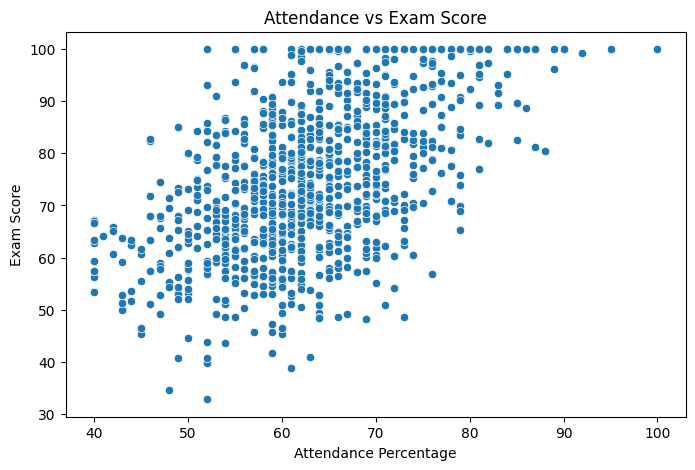

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Attendance_Rate_Percentage',
    y='Exam_Score',
    data=df
)

plt.title("Attendance vs Exam Score")
plt.xlabel("Attendance Percentage")
plt.ylabel("Exam Score")

plt.show()

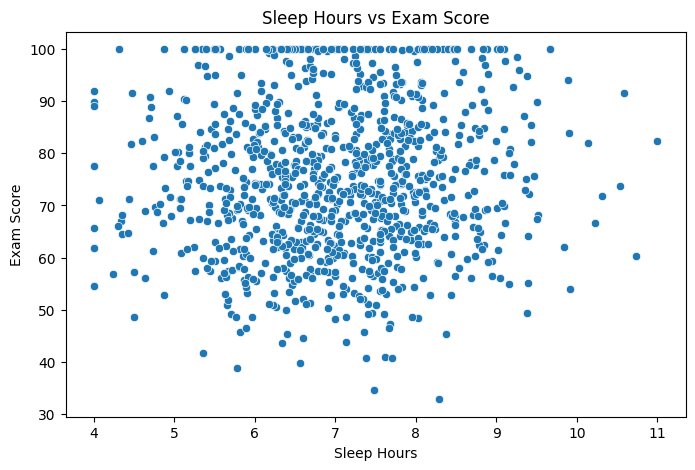

In [18]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Sleep_Hours_Per_Day',
    y='Exam_Score',
    data=df
)

plt.title("Sleep Hours vs Exam Score")
plt.xlabel("Sleep Hours")
plt.ylabel("Exam Score")

plt.show()

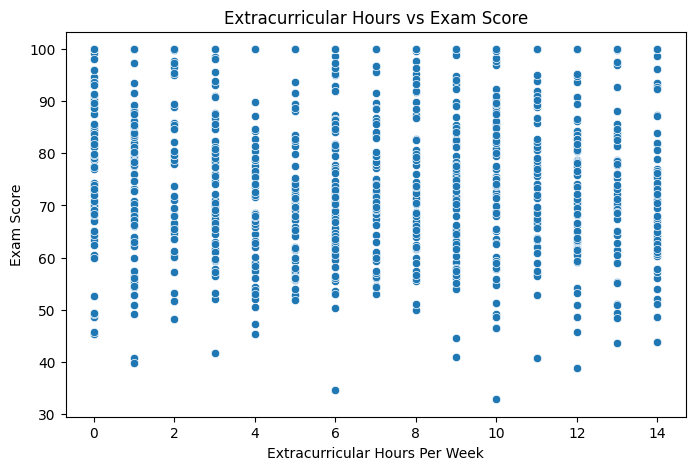

In [20]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='Extracurricular_Hours_Per_Week',
    y='Exam_Score',
    data=df
)

plt.title("Extracurricular Hours vs Exam Score")
plt.xlabel("Extracurricular Hours Per Week")
plt.ylabel("Exam Score")

plt.show()

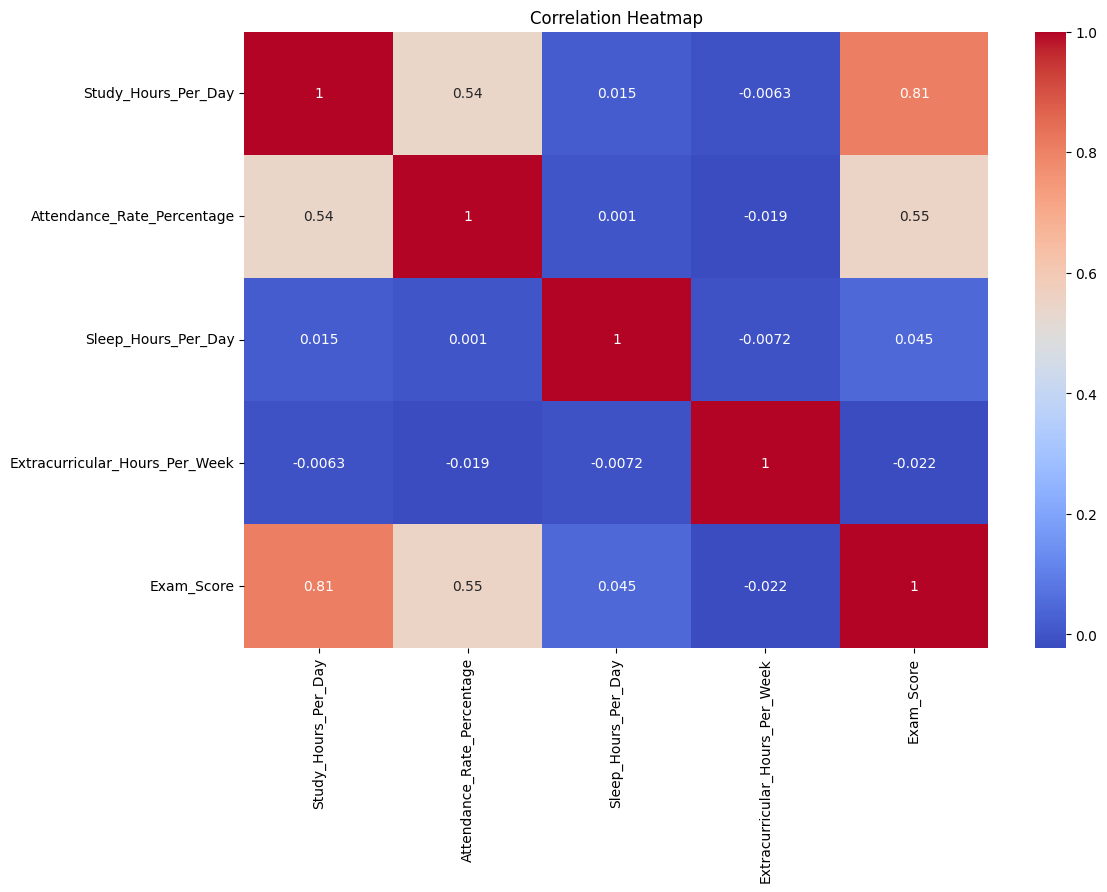

In [17]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

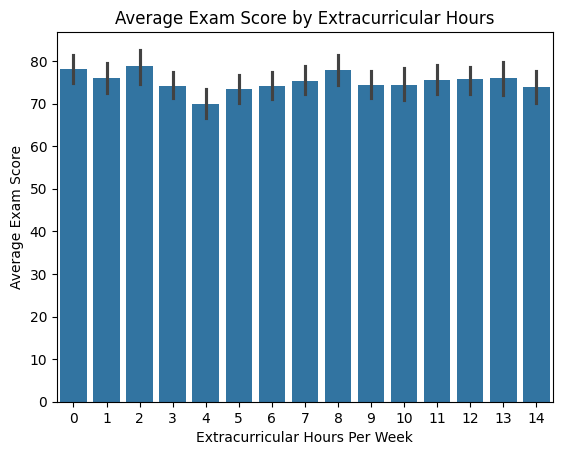

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(
    x='Extracurricular_Hours_Per_Week',
    y='Exam_Score',
    data=df
)

plt.title("Average Exam Score by Extracurricular Hours")
plt.xlabel("Extracurricular Hours Per Week")
plt.ylabel("Average Exam Score")

plt.show()

In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [24]:
df = pd.read_csv("student_performance_dataset.csv")

In [26]:
df['Passed'] = df['Passed'].map({'Yes':1, 'No':0})

In [28]:
X = df[['Study_Hours_Per_Day',
        'Attendance_Rate_Percentage',
        'Sleep_Hours_Per_Day',
        'Extracurricular_Hours_Per_Week']]

y = df['Exam_Score']

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [30]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [31]:
y_pred = model.predict(X_test)

In [32]:
mae = mean_absolute_error(y_test, y_pred)

print("MAE:", mae)

MAE: 6.4516802026475215


In [33]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("RMSE:", rmse)

RMSE: 8.760269528566585


In [34]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.6175625014699698


In [37]:
import pandas as pd

input_data = pd.DataFrame([[
    study_hours,
    attendance,
    sleep_hours,
    extracurricular_hours
]], columns=[
    'Study_Hours_Per_Day',
    'Attendance_Rate_Percentage',
    'Sleep_Hours_Per_Day',
    'Extracurricular_Hours_Per_Week'
])

predicted_score = model.predict(input_data)

print("Predicted Final Exam Score:", predicted_score[0])

Predicted Final Exam Score: 94.05394380250159


In [38]:
import pandas as pd

try:
    study_hours = float(input("Enter study hours per day: "))
    attendance = float(input("Enter attendance percentage: "))
    sleep_hours = float(input("Enter sleep hours per day: "))
    extracurricular_hours = float(input("Enter extracurricular hours per week: "))

    # Validation
    if study_hours < 0 or attendance < 0 or sleep_hours < 0 or extracurricular_hours < 0:
        print("Values cannot be negative!")

    elif attendance > 100:
        print("Attendance percentage cannot exceed 100!")

    else:
        input_data = pd.DataFrame([[
            study_hours,
            attendance,
            sleep_hours,
            extracurricular_hours
        ]], columns=[
            'Study_Hours_Per_Day',
            'Attendance_Rate_Percentage',
            'Sleep_Hours_Per_Day',
            'Extracurricular_Hours_Per_Week'
        ])

        predicted_score = model.predict(input_data)

        print("Predicted Final Exam Score:", predicted_score[0])

except ValueError:
    print("Invalid input! Please enter numeric values only.")

Enter study hours per day: -7
Enter attendance percentage: 123
Enter sleep hours per day: 25
Enter extracurricular hours per week: 99
Values cannot be negative!
